In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [2]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '2'
source = '15'

data = f'{path}{date}/export_txt'

In [3]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,2]
mag1_error=data1[:,3]

In [4]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
#mag_c1=mag1-mag_mean1
mag_c1=mag1

In [5]:
#data1 = np.loadtxt('11bocet_pol.txt',skiprows=0)

#t2=data1[:,0]
#mag2=data1[:,1]
#mag2_error=data1[:,2]

In [6]:
# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [7]:
#data1 = np.loadtxt('12bocet_pol.txt',skiprows=0)

#t3=data1[:,0]
#mag3=data1[:,1]
#mag3_error=data1[:,2]

In [8]:
# Removendo a media dos dados

#mag_mean3=np.mean(mag3)
#mag_c3=mag3-mag_mean3
#mag_c3=mag3

In [9]:
#data1 = np.loadtxt('19bocet_pol.txt',skiprows=0)

#t4=data1[:,0]
#mag4=data1[:,1]
#mag4_error=data1[:,2]

In [10]:
# Removendo a media dos dados
#
#mag_mean4=np.mean(mag4)
#mag_c4=mag4-mag_mean4
#mag_c4=mag4

In [11]:
time=t1
mag_c=mag_c1
mag_error=mag1_error
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [12]:
#  Filter data
#
filter="no"
# filter="yes"

In [13]:
##### Lomb Scargle
#
# limites em minutos
p1=10.
p2=20.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [14]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.01086956947070535
Best period in hours   0.2608696672969284
Best period in minutes   15.652180037815704
False alarm probability of 0.001   [0.05307998]
 


In [15]:
best_period*60*24

15.652180037815704

In [16]:
927/60

15.45

In [17]:
((927.66/60)/60)/24

0.010736805555555555

In [18]:
#best_period=((927.66/60)/60)/24

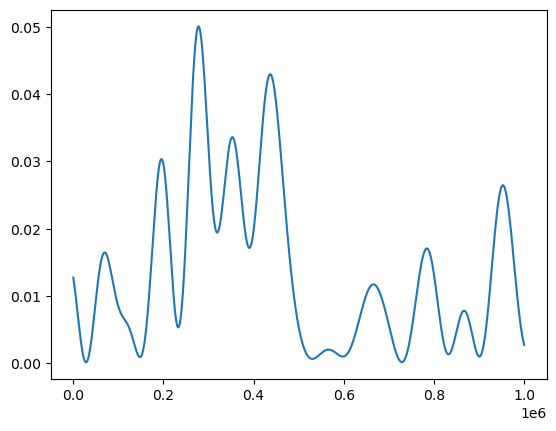

In [19]:
plt.plot(power)

In [20]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [21]:
phase

array([0.13743241, 0.17219346, 0.20690862, 0.24166546, 0.27641896,
       0.31106665, 0.34575263, 0.38053278, 0.41528479, 0.45025982,
       0.48501611, 0.5197212 , 0.55447642, 0.58917461, 0.62399897,
       0.65870728, 0.69361154, 0.72830973, 0.76300416, 0.79783182,
       0.8325609 , 0.86730597, 0.90200947, 0.93664756, 0.97143041,
       0.00631124, 0.04114412, 0.07580509, 0.1104921 , 0.1451972 ,
       0.17988472, 0.21473308, 0.24959797, 0.28442764, 0.31906834,
       0.35377935, 0.3885068 , 0.42319652, 0.45795807, 0.49269619,
       0.52745351, 0.56226459, 0.59701394, 0.63171633, 0.66643745,
       0.70111971, 0.73596694, 0.77070078, 0.80547888, 0.84019999,
       0.87500679, 0.9097423 , 0.94447618, 0.9792574 , 0.01394124,
       0.04867774, 0.08334937, 0.11842611, 0.15321423, 0.18795346,
       0.22272247, 0.25735954, 0.29222532, 0.32692305, 0.36187572,
       0.39670162, 0.43141053, 0.46617581, 0.50091822, 0.53575805,
       0.57050679, 0.60524659, 0.63996277, 0.67489107, 0.70957

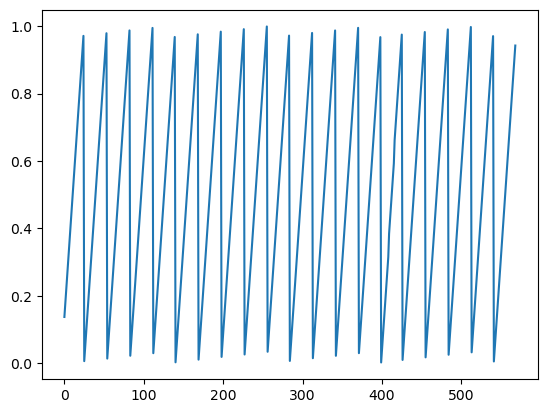

In [22]:
plt.plot(phase)

In [23]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [24]:
number_bins

6

In [25]:
center_bin

array([0., 0., 0., 0., 0., 0.])

In [26]:
bin_means

array([0., 0., 0., 0., 0., 0.])

In [27]:
bin_size

0.16666666666666666

In [28]:
bins

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [29]:
digitized

array([1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6,
       6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6,
       6, 6, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5,
       5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5,
       5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4,

In [30]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

1 0.08333333333333333 -9.960648368959783
2 0.25 -9.946861249233333
3 0.4166666666666667 -9.924572851777896
4 0.5833333333333333 -9.896801233665625
5 0.7499999999999999 -9.906291352089584
6 0.9166666666666666 -9.938956938254258


In [31]:
mag_c

array([ -9.90841116,  -9.92250722,  -9.92505184,  -9.92744361,
        -9.92603029,  -9.92183613,  -9.91982949,  -9.91910213,
        -9.90467978,  -9.8869767 ,  -9.8701309 ,  -9.84850519,
        -9.82883544,  -9.8145795 ,  -9.80448149,  -9.78984116,
        -9.78674787,  -9.79348767,  -9.80944008,  -9.83965926,
        -9.87218383,  -9.89021966,  -9.9027639 ,  -9.91787577,
        -9.92894652,  -9.93604916,  -9.93739521,  -9.922312  ,
        -9.90609701,  -9.89981103,  -9.8845654 ,  -9.86066861,
        -9.83797547,  -9.81289152,  -9.78073231,  -9.75261324,
        -9.72387139,  -9.69735232,  -9.6728008 ,  -9.65861485,
        -9.65828045,  -9.66645355,  -9.67837198,  -9.70389444,
        -9.72974322,  -9.74823256,  -9.7739889 ,  -9.79367951,
        -9.80084732,  -9.80414051,  -9.80194585,  -9.79627818,
        -9.78816186,  -9.78782479,  -9.79849349,  -9.81908631,
        -9.84391817,  -9.8744093 ,  -9.92076312,  -9.95747932,
        -9.9848505 ,  -9.99733146, -10.00013194,  -9.99

In [32]:
len(mag_c)

569

In [33]:
mag_c[digitized==1]

array([ -9.90841116,  -9.93604916,  -9.93739521,  -9.922312  ,
        -9.90609701,  -9.89981103,  -9.79849349,  -9.81908631,
        -9.84391817,  -9.8744093 ,  -9.92076312, -10.06391667,
       -10.05747276, -10.03845063, -10.02093383, -10.01062418,
        -9.96804469,  -9.94772177,  -9.93858972,  -9.93683455,
       -10.07869029, -10.10169299, -10.10966626, -10.10812908,
       -10.09141185,  -9.94575406,  -9.93913596,  -9.92149901,
        -9.91318201,  -9.91356736,  -9.7579117 ,  -9.77104395,
        -9.78100407,  -9.80159805,  -9.82200796, -10.00540805,
       -10.02557637, -10.0384523 , -10.04895428, -10.064327  ,
        -9.95445061,  -9.95017953,  -9.93593189,  -9.93092829,
        -9.88144544,  -9.89955988,  -9.92239659,  -9.93600647,
        -9.94446386,  -9.96523211,  -9.96883365,  -9.96577733,
        -9.9697359 ,  -9.96507966,  -9.93206527,  -9.95091939,
        -9.96347892,  -9.97302682,  -9.98792857,  -9.96092668,
        -9.93362952,  -9.90838893,  -9.89374722,  -9.84

In [34]:
bin_means

array([-9.96064837, -9.94686125, -9.92457285, -9.89680123, -9.90629135,
       -9.93895694])

In [35]:
y_fit

array([-9.9725366 , -9.97106163, -9.96830488, -9.9643906 , -9.95950782,
       -9.95390606, -9.94782939, -9.94155417, -9.93539972, -9.9296183 ,
       -9.92455735, -9.92042482, -9.91740495, -9.91564966, -9.91523711,
       -9.91619029, -9.91847678, -9.92196151, -9.92648863, -9.93186604,
       -9.93780434, -9.94403895, -9.95026395, -9.95618116, -9.96154401,
       -9.96608317, -9.96956147, -9.97181186, -9.97274815, -9.9723233 ,
       -9.97055781, -9.96751862, -9.96335373, -9.95826891, -9.95253566,
       -9.94638654, -9.94012099, -9.93404537, -9.92842945, -9.92355592,
       -9.91965021, -9.91689749, -9.91543718, -9.91533188, -9.91658474,
       -9.91913325, -9.92287779, -9.92761358, -9.93313374, -9.9391601 ,
       -9.94543096, -9.95162079, -9.95744837, -9.96264407, -9.96694184,
       -9.97015793, -9.97213002, -9.97277142, -9.97203232, -9.96996262,
       -9.96665714, -9.96229265, -9.95702788, -9.95116941, -9.94492501,
       -9.93865828, -9.93266533, -9.92720061, -9.92253661, -9.91

In [36]:
len(y_fit)

569

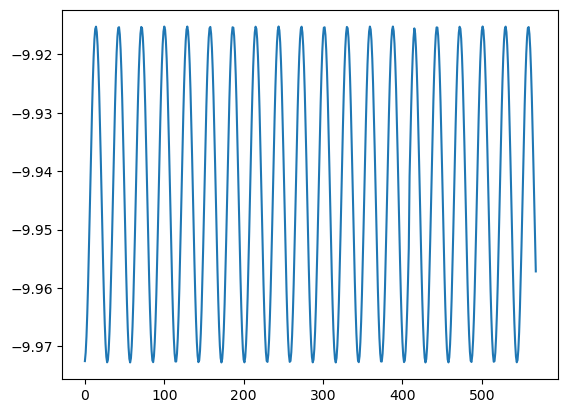

In [37]:
plt.plot(y_fit)

In [38]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

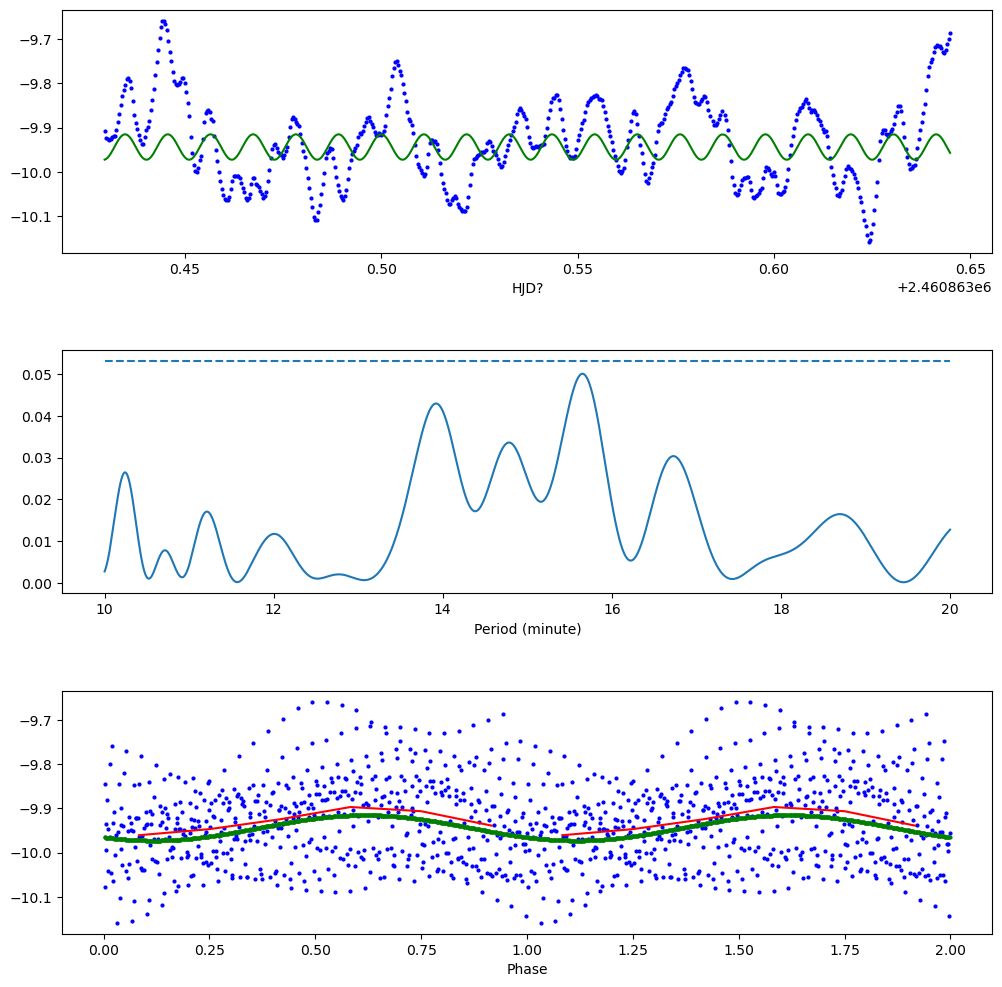

In [39]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()